# Task 1: Time-series preprocessing, analysis and forecasting

## tl;dr

The dataset contains hourly traffic and weather observations for westbound I-94 from October 2012 to September 2018. Repeated timestamps were aggregated because one hour can contain more than one weather description. Short gaps up to three hours were interpolated, while longer gaps were kept missing so that we do not create too much artificial history.

Traffic has a strong hour-of-day and weekday pattern. Lagged traffic values are highly useful, and moving averages make the underlying daily and weekly levels easier to see. The selected random forest achieved a test RMSE of **233.21 vehicles/hour**, MAE of **147.79**, and R-squared of **0.9861** on the final chronological test period.

## Context & Methods

The forecasting target is `traffic_volume`, the number of westbound vehicles recorded in an hour. We use a chronological 70/15/15 split rather than a random split because a random split would allow future patterns to leak into training.

### Key assumptions

- Repeated timestamps describe the same traffic hour under multiple weather labels, so numeric weather values and traffic are averaged and categorical weather is combined.
- The text value `None` in the holiday column means a normal day. It is changed to `No Holiday`; it is not treated as an unknown missing value.
- Only internal gaps of three hours or less are interpolated. Longer gaps remain missing and model rows that depend on them are dropped.
- Lag and moving-average features are shifted by one hour. Therefore the current target is never included in its own predictors.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# Rebuild all data, figures, tables and the model from the raw CSV.
from scripts.run_analysis import main
main()

                                                        value
raw_rows                                                48204
raw_columns                                                 9
start                                     2012-10-02 09:00:00
end                                       2018-09-30 23:00:00
full_duplicate_rows                                        17
repeated_timestamp_rows                                  7629
unique_observed_hours                                   40575
expected_hours                                          52551
missing_hours_before_short_interpolation                11976
remaining_missing_targets                                8797

Model experiments:
 experiment  n_estimators  max_depth  min_samples_leaf  validation_mae  validation_rmse  validation_r2
      RF-2           100       18.0                 2      158.860674       246.295758       0.984457
      RF-3           140        NaN                 2      158.923057       246.611864       

## Data

The raw file has nine columns: timestamp, holiday, four numeric weather measures, two weather descriptions, and the traffic target. The intended granularity is hourly, but the raw timeline contains repeated timestamps and missing hours. The next cells show the saved quality summary and descriptive statistics.

In [2]:
quality = pd.read_csv(ROOT / "outputs/tables/data_quality_summary.csv", index_col=0)
quality

,value
raw_rows,48204
raw_columns,9
start,2012-10-02 09:00:00
end,2018-09-30 23:00:00
full_duplicate_rows,17
repeated_timestamp_rows,7629
unique_observed_hours,40575
expected_hours,52551
missing_hours_before_short_interpolation,11976
remaining_missing_targets,8797


In [3]:
statistics = pd.read_csv(ROOT / "outputs/tables/descriptive_statistics.csv", index_col=0)
statistics.loc[["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"], ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,count,mean,std,min,25%,50%,75%,max
temp,40575.0,281.3158822222222,13.817217,0.0,271.84,282.86,292.28,310.07
rain_1h,40575.0,0.3186293284041897,48.812640,0.0,0.0,0.0,0.0,9831.3
snow_1h,40575.0,0.0001173136167590881,0.005676,0.0,0.0,0.0,0.0,0.51
clouds_all,40575.0,44.20121503388786,38.681283,0.0,1.0,40.0,90.0,100.0
traffic_volume,40575.0,3290.650474430068,1984.772909,0.0,1248.5,3427.0,4952.0,7280.0


## Results

### Question 1: Does traffic show an increasing or decreasing long-term trend?

Monthly traffic changes across the six years, but it does not follow one smooth straight trend. The average in the last twelve months was **3,333 vehicles/hour**, compared with **3,306** in the first twelve months, a change of **0.8%**. Seasonal changes and gaps mean this should be interpreted as descriptive, not a causal change.

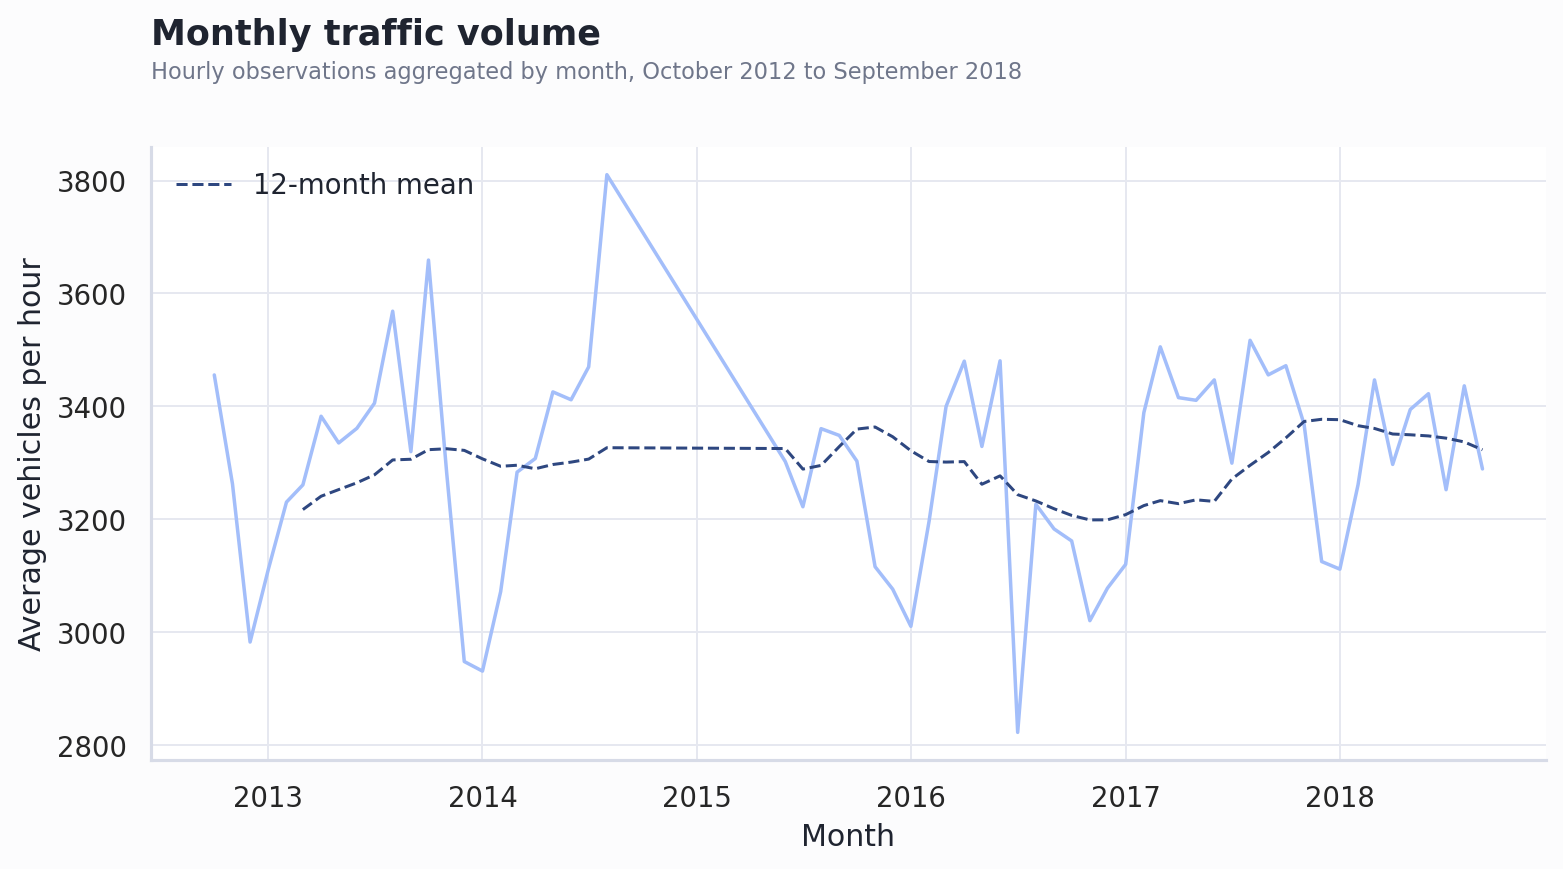

In [4]:
display(Image(filename=ROOT / 'outputs/figures/q1_monthly_trend.png'))

### Question 2: Which weekday and hour combinations have the highest traffic?

The heatmap shows a strong commuting cycle. The highest mean occurs on **Wednesday at 16:00**, with about **6,414 vehicles/hour**. Weekday morning and afternoon periods are clearly busier, while overnight hours and weekends are lower. This pattern supports using hour, weekday and weekend features in the model.

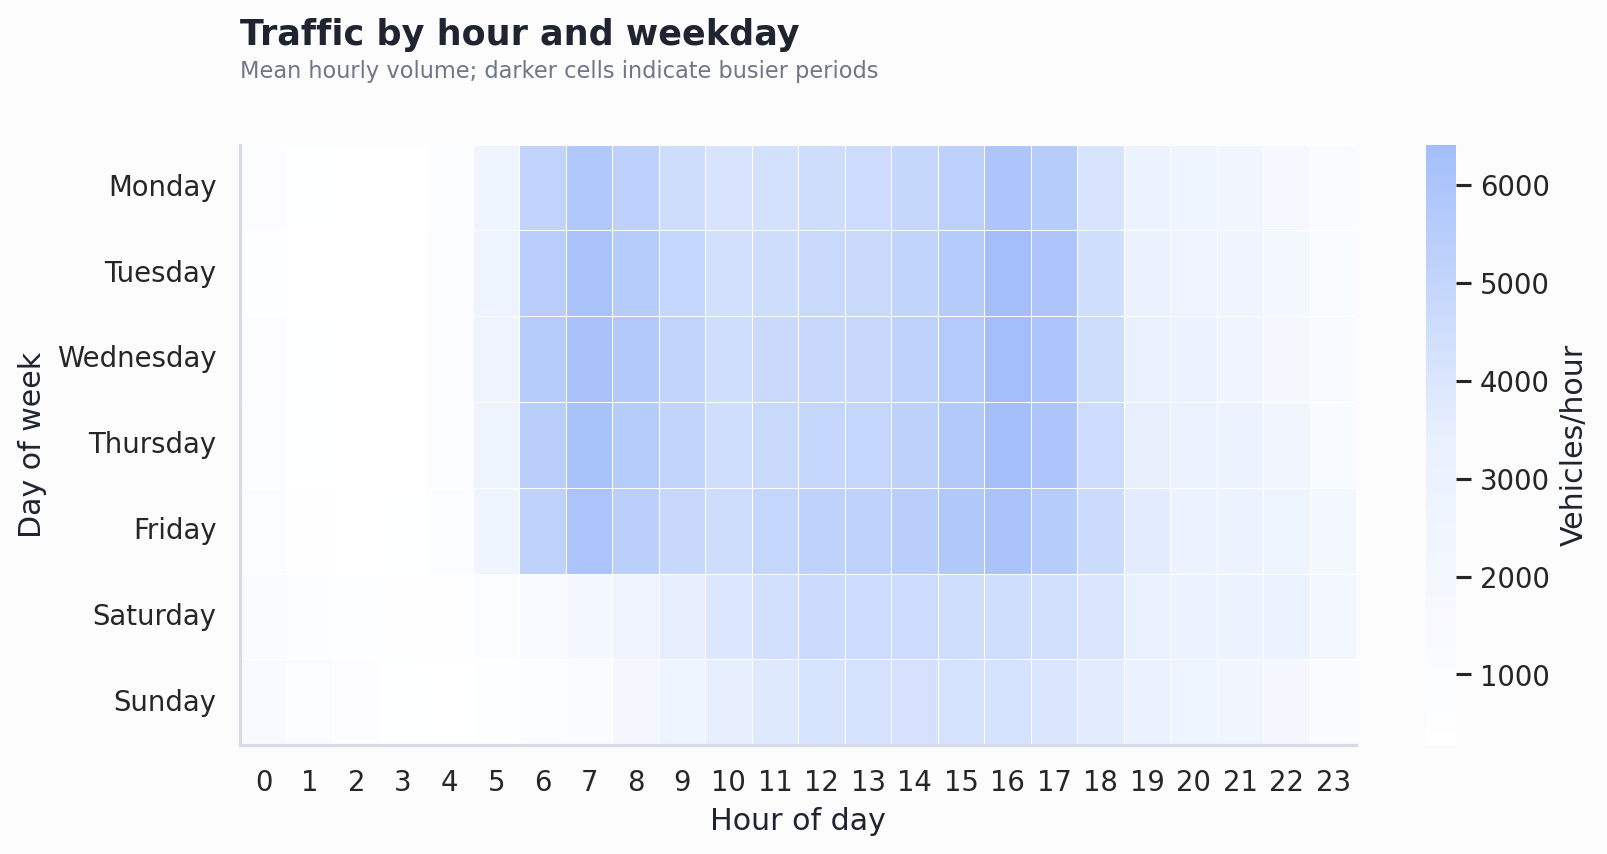

In [5]:
display(Image(filename=ROOT / 'outputs/figures/q2_hour_weekday_heatmap.png'))

### Question 3: Does traffic volume differ across weather conditions?

Among weather categories with at least 100 observations, **Clouds** has the highest mean traffic at about **3,617 vehicles/hour**, while **Fog** has the lowest at about **2,640**. Weather is associated with traffic, but this comparison is also affected by time of day and season, so it does not prove weather caused the difference.

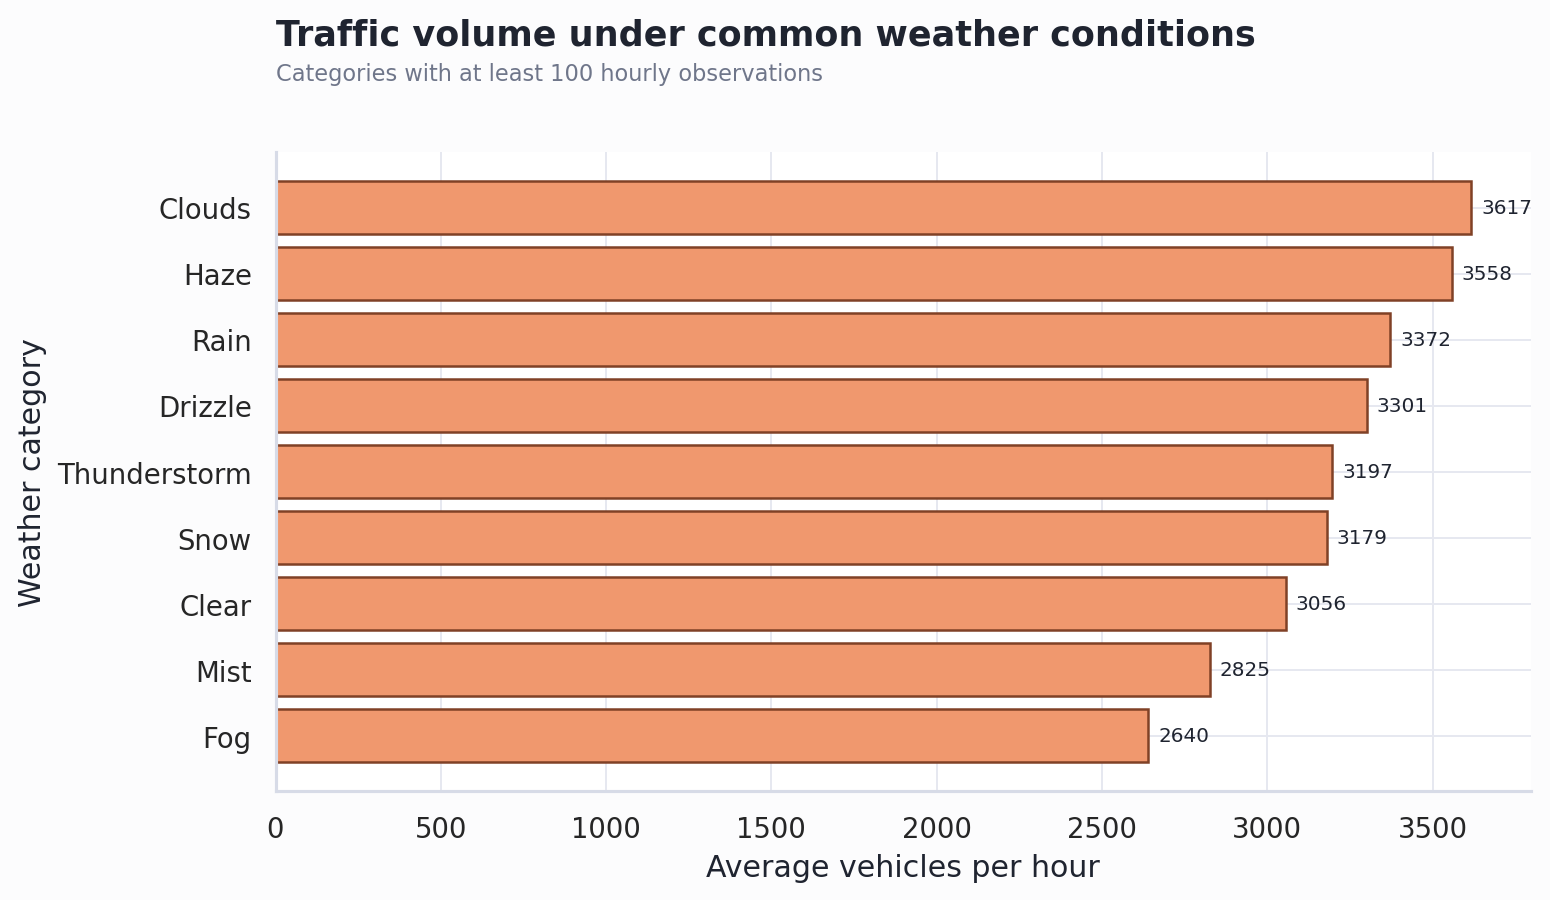

In [6]:
display(Image(filename=ROOT / 'outputs/figures/q3_weather_comparison.png'))

### Question 4: Is current traffic related to traffic 1, 24 and 168 hours earlier?

Yes. The correlations are **Previous hour: 0.916, Same hour yesterday: 0.861, Same hour last week: 0.944**. The same-hour previous-day and previous-week lags capture repeated travel schedules, while the one-hour lag captures short-term continuity. These strong relationships justify lagged features in the forecasting model. Correlation still does not mean every individual hour behaves the same.

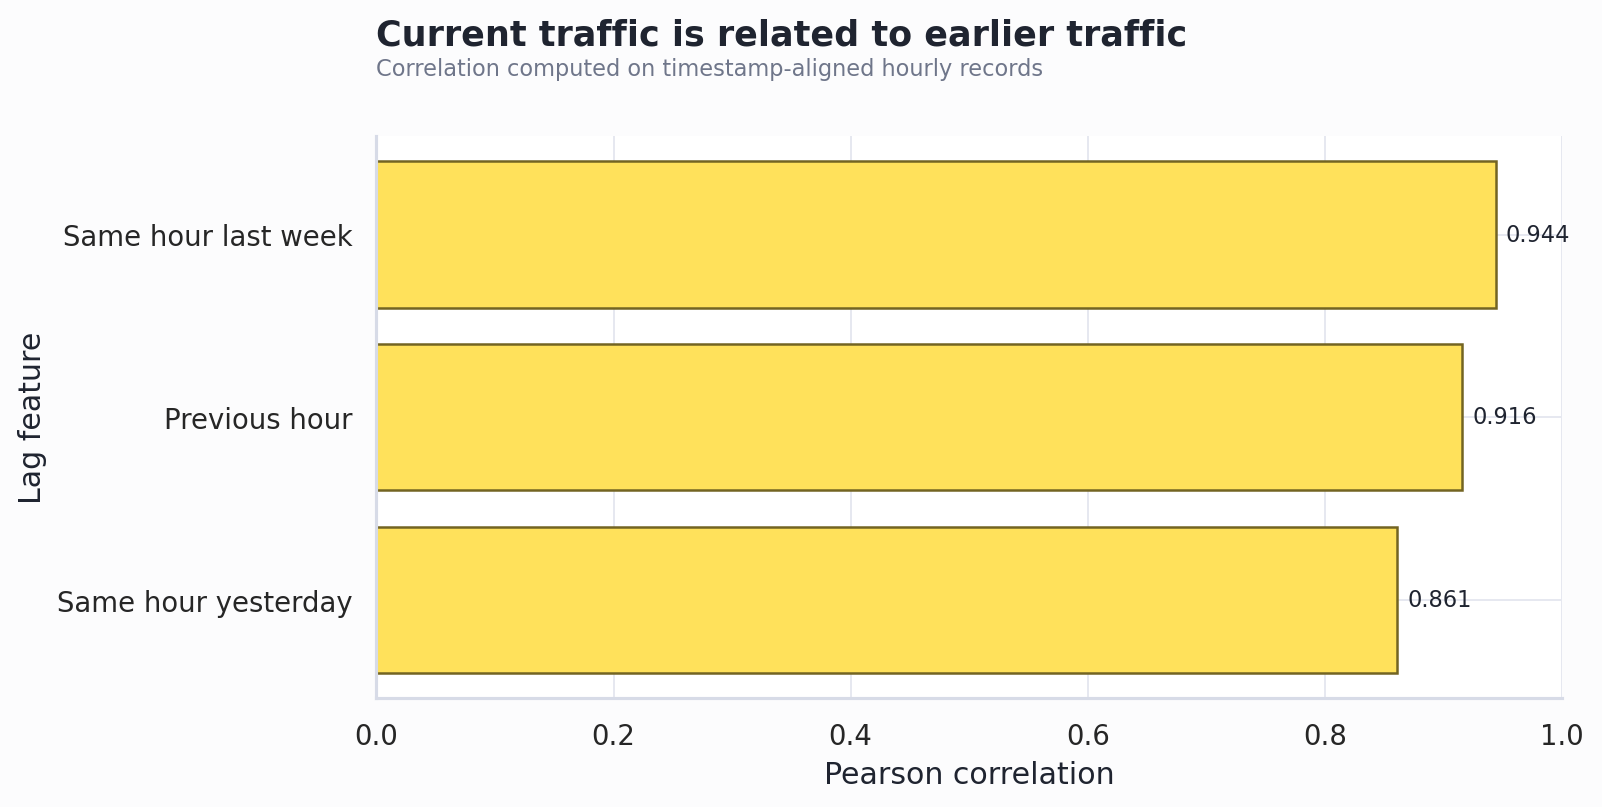

In [7]:
display(Image(filename=ROOT / 'outputs/figures/q4_lag_correlations.png'))

### Question 5: What do 24-hour and 168-hour moving averages reveal?

The raw hourly series is volatile, with a standard deviation of **1,956 vehicles/hour** during August 2018. The 24-hour moving average reduces this to **370**, and the 168-hour moving average reduces it further to **45**. The weekly average therefore shows the baseline level clearly, while the daily average reacts faster. Both averages use only earlier observations to prevent leakage.

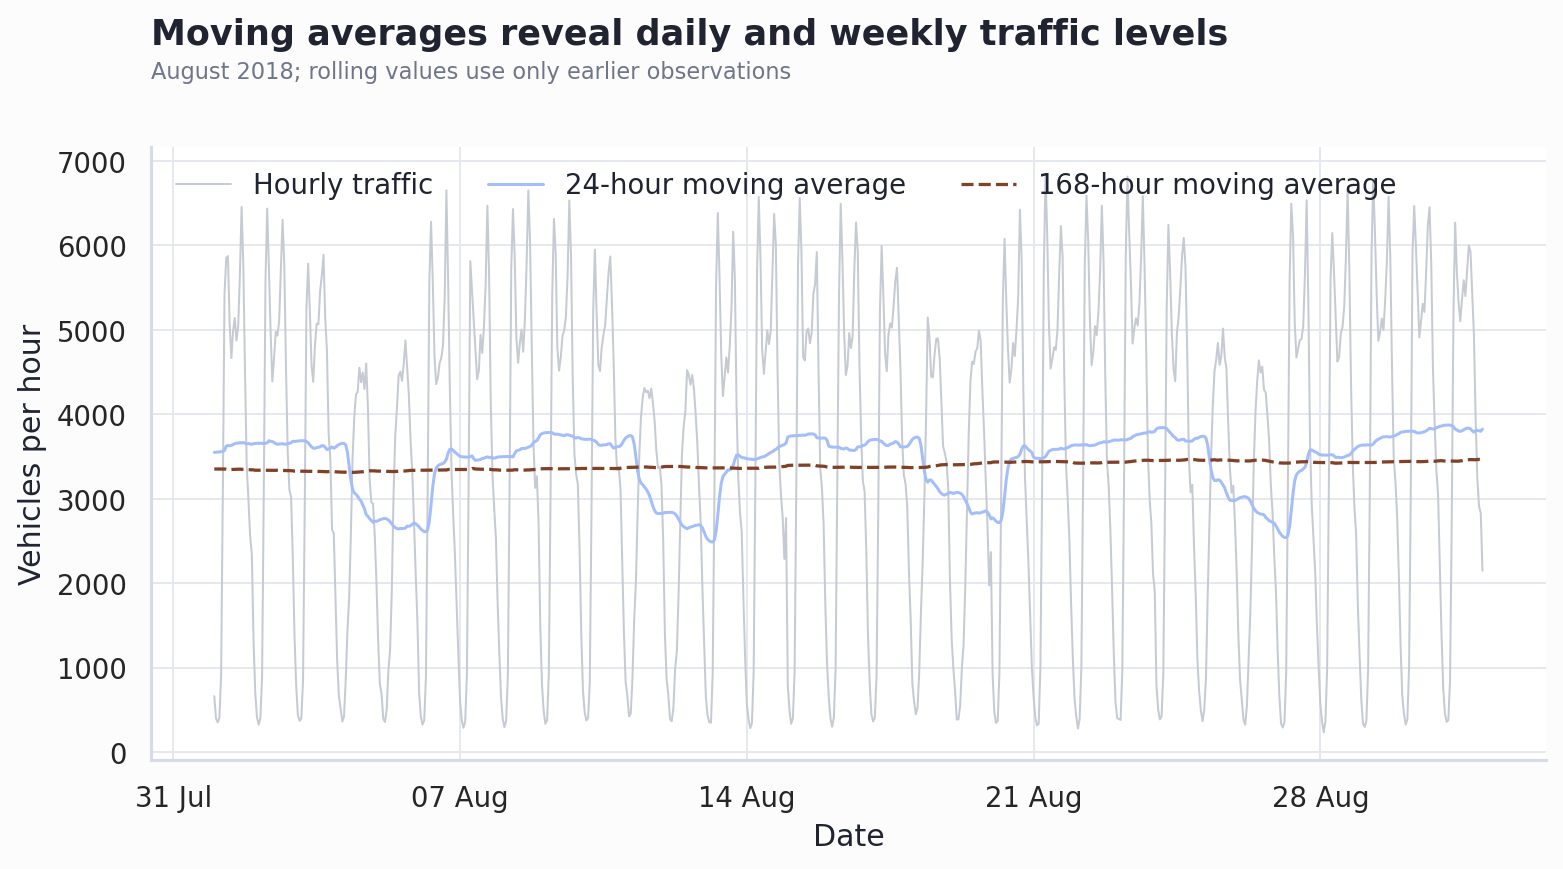

In [8]:
display(Image(filename=ROOT / 'outputs/figures/q5_moving_averages.png'))

### Question 6: How does traffic differ across temperature ranges?

Traffic volume is not a simple linear function of temperature. Moderate temperature bands contain many normal commuting days and generally have higher mean traffic than extreme cold or heat bands. Temperature may be useful, but calendar and lag variables are more direct predictors of repeated travel behaviour.

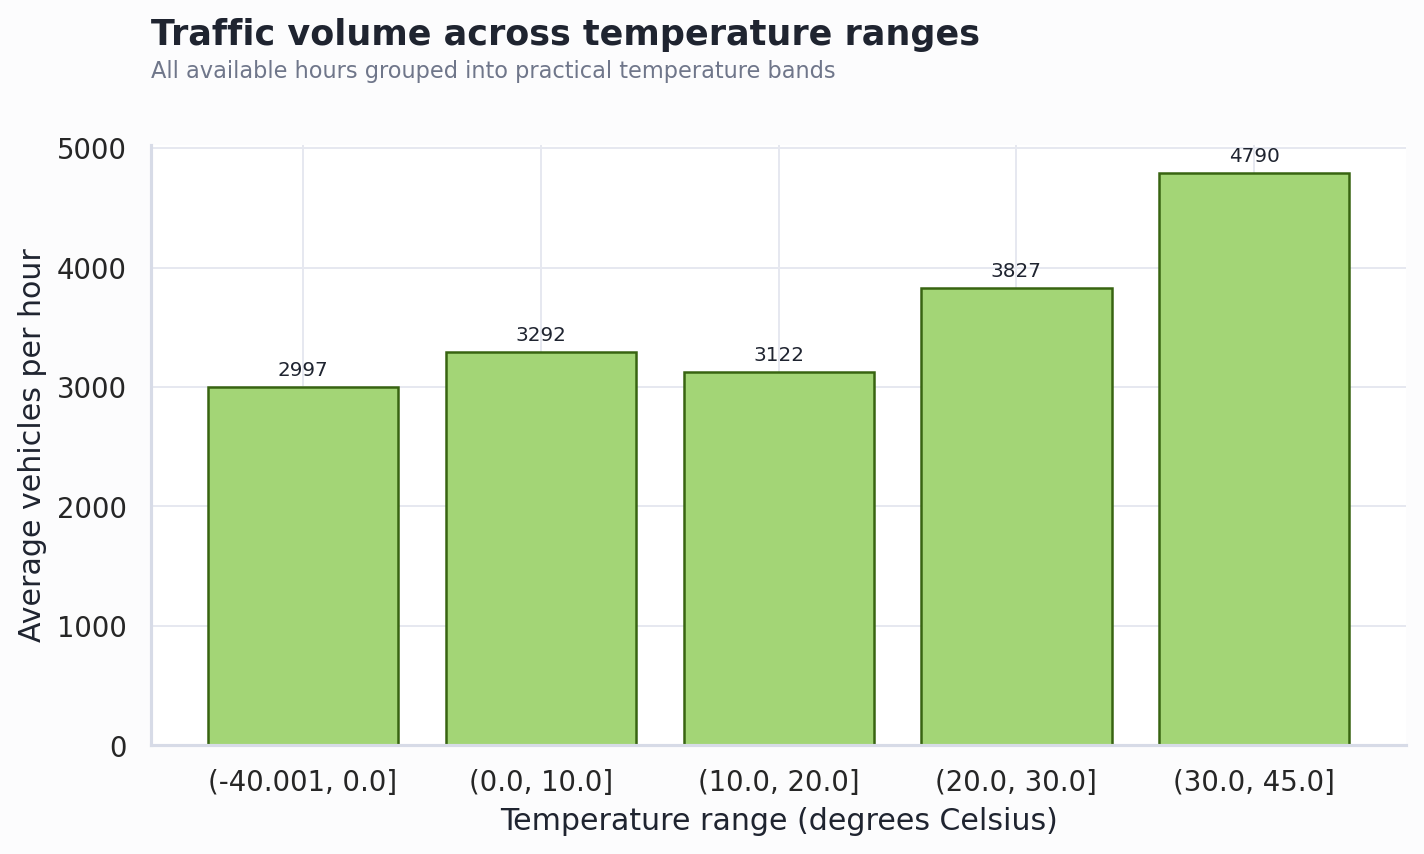

In [9]:
display(Image(filename=ROOT / 'outputs/figures/q6_temperature_bands.png'))

## Model experiments

Three random forest configurations were tuned using the middle chronological validation period. RMSE is the main selection metric because it penalizes large forecast errors, while MAE gives an easier average-error interpretation. The best configuration is refitted on the combined training and validation periods, then evaluated once on the untouched final test period.

In [10]:
experiments = pd.read_csv(ROOT / "outputs/tables/model_experiments.csv")
experiments.round(4)

,experiment,n_estimators,max_depth,min_samples_leaf,validation_mae,validation_rmse,validation_r2
0,RF-2,100,18.0,2,158.8607,246.2958,0.9845
1,RF-3,140,NaN,2,158.9231,246.6119,0.9844
2,RF-1,60,12.0,4,163.9430,253.7051,0.9835


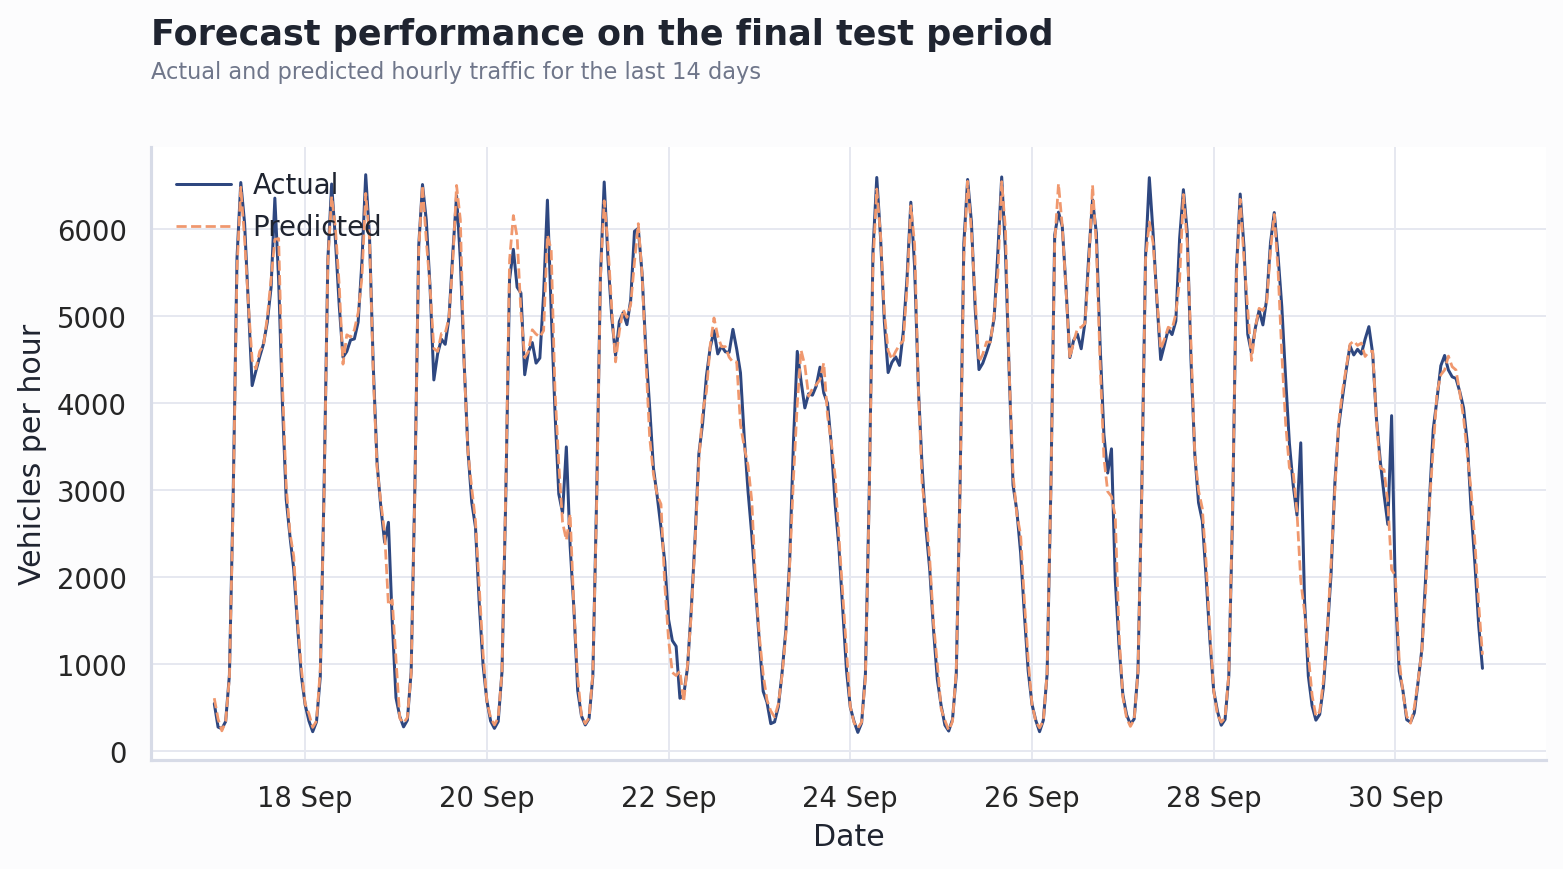

In [11]:
display(Image(filename=ROOT / 'outputs/figures/model_test_predictions.png'))

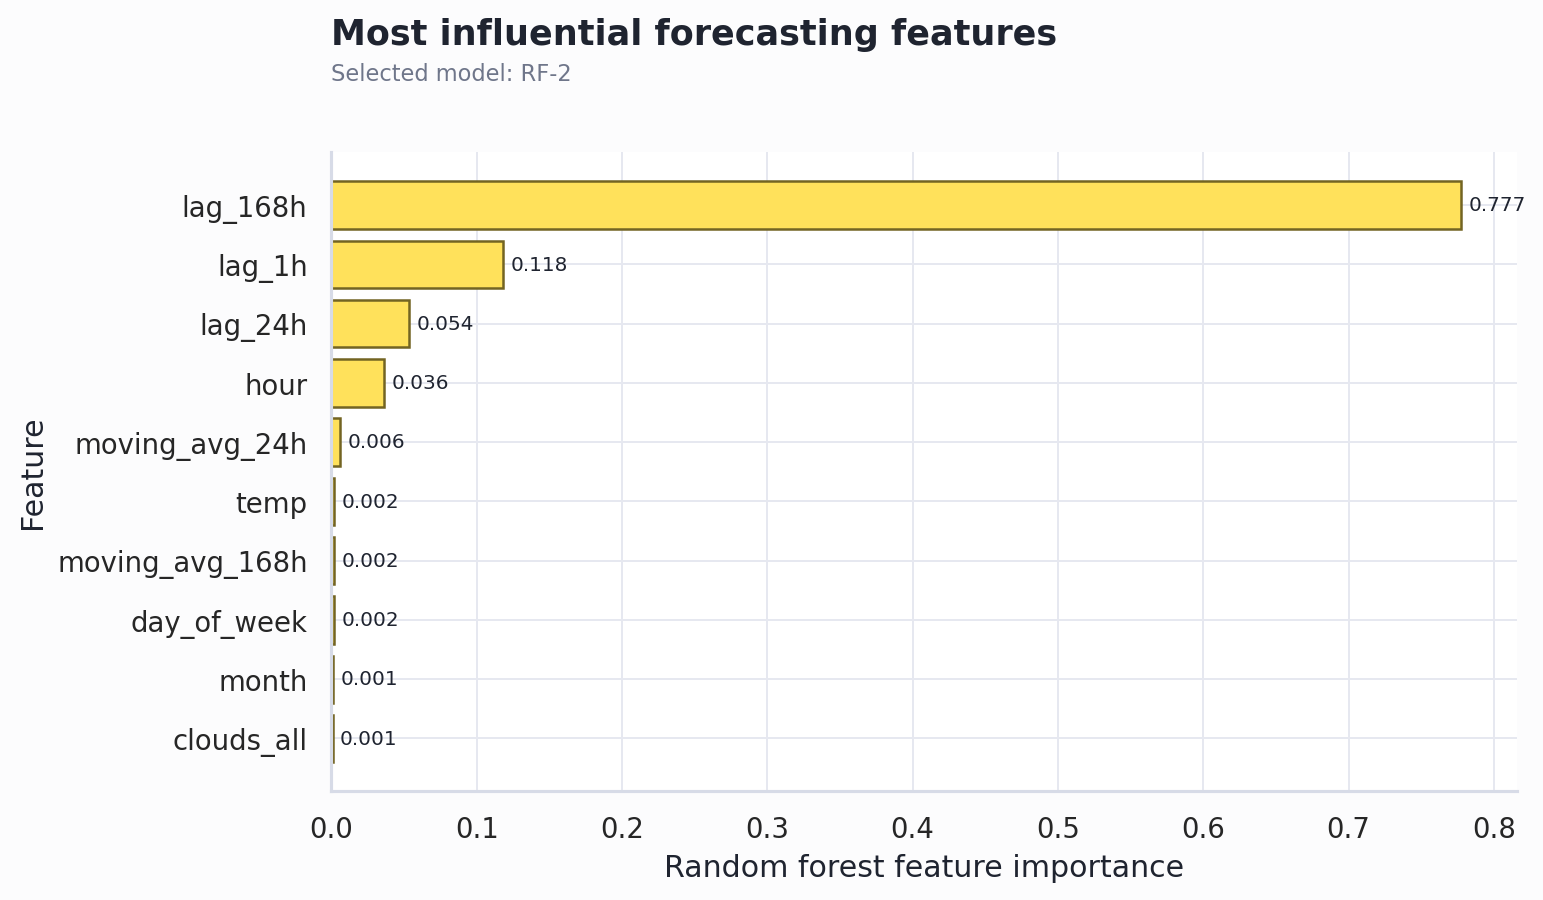

In [12]:
display(Image(filename=ROOT / 'outputs/figures/model_feature_importance.png'))

## Takeaways

- Traffic forecasting is mainly driven by repeated hourly and weekly behaviour.
- Lagged values and past-only moving averages are important and also satisfy the time-series feature requirement.
- Weather adds context, although descriptive weather comparisons are confounded by season and time of day.
- The selected model generalizes well to the final chronological period, but its performance applies to this I-94 station and should not be assumed for other roads.
- A future improvement would compare this random forest with a seasonal naive baseline and a gradient boosting model over several rolling validation windows.